# Market Basket Analysis — Online Retail Dataset

I wanted to practice association rule mining on a real transaction dataset, so I picked
the UCI Online Retail dataset (541,909 line items from a UK-based online gift retailer,
Dec 2010–Dec 2011) and set myself a concrete question: which products do customers
actually tend to buy together, and could that be turned into a "customers also bought"
recommendation worth showing at checkout?

**Method:** Apriori for frequent itemset mining, then association rules (support,
confidence, lift). The first pass I ran was dominated by pairs like "red alarm clock →
green alarm clock" — technically a strong statistical signal, but useless as an actual
recommendation. So I added a filtering step afterward to strip out same-product
color/size variants and keep only genuinely different product pairings.

**Sections:**
1. Load and inspect the data
2. Clean the data
3. Baseline revenue metrics
4. Build the basket matrix
5. Mine frequent itemsets and association rules
6. Filter out variant-pair noise
7. Visualize the cross-sell pairs
8. Estimate business impact
9. Key findings


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import re
from mlxtend.frequent_patterns import apriori, association_rules

## 1. Load and inspect the data

In [2]:
df = pd.read_excel('Online_Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Clean the data

Before I could trust any "bought together" pattern, I had to get rid of the noise that's
typical of raw e-commerce exports: returns, cancelled orders, guest checkouts with no
customer ID, and non-product rows like postage and bank fees. Leaving any of these in
would create false co-purchase signals — a return isn't a purchase, and "postage" isn't
a product someone chose to buy alongside something else.

In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Negative quantities (returns):", (df['Quantity'] < 0).sum())
print("Zero/negative prices:", (df['UnitPrice'] <= 0).sum())
print("Invoices starting with 'C' (cancellations):",
      df['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Unique invoices:", df['InvoiceNo'].nunique())
print("Unique products:", df['StockCode'].nunique())
print("Unique customers:", df['CustomerID'].nunique())

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Negative quantities (returns): 10624
Zero/negative prices: 2517


Invoices starting with 'C' (cancellations): 9288
Unique invoices: 25900
Unique products: 4070
Unique customers: 4372


In [4]:
clean = df.copy()

# 1. Remove rows with no CustomerID (guest checkouts can't be tied to a basket pattern reliably)
clean = clean.dropna(subset=['CustomerID'])

# 2. Remove returns (negative quantity)
clean = clean[clean['Quantity'] > 0]

# 3. Remove cancelled invoices (start with 'C')
clean = clean[~clean['InvoiceNo'].astype(str).str.startswith('C')]

# 4. Remove zero/negative prices
clean = clean[clean['UnitPrice'] > 0]

# 5. Remove non-product stock codes (postage, fees, samples, test rows)
bad_codes = ['POST', 'D', 'M', 'BANK CHARGES', 'PADS', 'CRUK',
             'AMAZONFEE', 'S', 'DOT', 'TEST001', 'TEST002']
clean = clean[~clean['StockCode'].astype(str).isin(bad_codes)]

# 6. Clean description text
clean = clean.dropna(subset=['Description'])
clean['Description'] = clean['Description'].str.strip().str.upper()

# 7. Normalize invoice numbers to string
clean['InvoiceNo'] = clean['InvoiceNo'].astype(str)

print("Rows after cleaning:", f"{len(clean):,}", f"(from {len(df):,} raw rows)")
print("Invoices after cleaning:", f"{clean['InvoiceNo'].nunique():,}")
print("Avg items per invoice:", round(len(clean) / clean['InvoiceNo'].nunique(), 2))
print("Max items in one invoice:", clean.groupby('InvoiceNo').size().max())

Rows after cleaning: 396,470 (from 541,909 raw rows)
Invoices after cleaning: 18,405
Avg items per invoice: 21.54
Max items in one invoice: 541


## 3. Baseline revenue metrics

I calculate average order value (AOV) here because it's the number I'll compare against
later, in Section 8, when I try to estimate what a recommendation feature might be worth.

In [5]:
clean['Revenue'] = clean['Quantity'] * clean['UnitPrice']

total_revenue = clean['Revenue'].sum()
order_revenue = clean.groupby('InvoiceNo')['Revenue'].sum()
baseline_aov = order_revenue.mean()

print(f"Total revenue (cleaned data): £{total_revenue:,.2f}")
print(f"Number of orders: {len(order_revenue):,}")
print(f"Baseline AOV: £{baseline_aov:.2f}")

Total revenue (cleaned data): £8,767,752.65
Number of orders: 18,405
Baseline AOV: £476.38


## 4. Build the basket matrix

Apriori needs the data in "one-hot" basket form: one row per order, one column per
product, 1 if that product was in the order and 0 if not. I also drop products that show
up in very few orders before mining — with under 100 orders out of 18,000+, they can't
form a statistically meaningful pattern, and keeping them just slows the algorithm down
for no real benefit.

In [6]:
basket = (clean.groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().fillna(0))
basket = basket.map(lambda x: 1 if x > 0 else 0)

print("Basket matrix shape (orders x products):", basket.shape)

min_support_count = 100
frequent_items = basket.columns[basket.sum() >= min_support_count]
# cast to bool: apriori is far faster and far lighter on memory on a true
# boolean matrix than on an int 0/1 matrix of the same shape
basket_filtered = basket[frequent_items].astype(bool)

print("Products before frequency filter:", basket.shape[1])
print("Products kept (appear in >=100 orders):", basket_filtered.shape[1])

Basket matrix shape (orders x products): (18405, 3861)
Products before frequency filter: 3861
Products kept (appear in >=100 orders): 1172


## 5. Mine frequent itemsets and association rules

Quick refresher on the three metrics I'm filtering on, since I keep having to look these
up myself:

**Support** — how often the itemset appears across all orders.
**Confidence** — of the orders containing the antecedent, what fraction also contain the
consequent.
**Lift** — how much more likely the consequent is to appear *given* the antecedent,
compared to its base rate. Lift > 1 means a real positive association; lift = 1 means no
relationship (co-occurring by chance).

I only keep rules that clear reasonable thresholds on all three, not just lift — a rule
with huge lift but tiny support is usually just two or three customers' coincidental
purchases, not a real pattern.

In [7]:
frequent_itemsets = apriori(
    basket_filtered,
    min_support=0.02,      # itemset must appear in at least 2% of orders
    use_colnames=True,
    max_len=3,              # pairs and triples only
    low_memory=True
)

print("Frequent itemsets found:", len(frequent_itemsets))

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
print("Raw association rules:", len(rules))

strong_rules = rules[
    (rules['confidence'] >= 0.5) &
    (rules['lift'] >= 2.0) &
    (rules['support'] >= 0.02)
].copy()
strong_rules = strong_rules.sort_values('lift', ascending=False).reset_index(drop=True)

print("Rules passing confidence >= 50%, lift >= 2.0, support >= 2%:", len(strong_rules))
strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Frequent itemsets found: 242
Raw association rules: 76
Rules passing confidence >= 50%, lift >= 2.0, support >= 2%: 32


,antecedents,consequents,support,confidence,lift
0,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER, GR...",0.021190,0.701439,23.863183
1,"frozenset({ROSES REGENCY TEACUP AND SAUCER, GR...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.021190,0.720887,23.863183
2,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.021190,0.564399,23.825164
3,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.021190,0.894495,23.825164
4,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.024993,0.827338,22.036408
5,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.024993,0.665702,22.036408
6,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER}),0.021190,0.847826,19.928786
7,frozenset({ROSES REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.023689,0.556833,18.432564
8,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER}),0.023689,0.784173,18.432564
9,frozenset({ROSES REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.029394,0.690932,18.403197


## 6. Filter out variant-pair noise

This is the part I almost missed. When I first looked at the raw rules, the top of the
list was dominated by pairs like "red alarm clock → green alarm clock" — a very strong
statistical pattern, but a useless recommendation: a customer who already bought the red
one isn't a great candidate for a nudge toward the same item in another color. Worse,
these pairs were inflating the lift ranking and pushing the genuinely interesting
cross-sell patterns further down the list.

So below, I strip color/size/material words out of each product name to get a "base
name", then drop any rule where the antecedent and consequent reduce to the same base
product. I also cap lift at 10 — in this dataset, anything above that is almost always a
near-duplicate pair that slipped past the base-name check rather than a real signal.

In [8]:
VARIANT_WORDS = [
    'GREEN', 'PINK', 'RED', 'BLUE', 'WHITE', 'BLACK', 'ROSES', 'YELLOW', 'ORANGE',
    'PURPLE', 'CREAM', 'IVORY', 'SILVER', 'GOLD', 'SMALL', 'LARGE', 'JUMBO', 'MINI',
    'RETROSPOT', 'POLKADOT', 'PAISLEY', 'VINTAGE', 'ANTIQUE', 'SET OF', 'PACK OF',
    'LITTLE', 'BIG', 'BABY', 'WOODEN', 'METAL', 'GLASS', 'CERAMIC'
]

def base_name(desc):
    d = desc.upper()
    for w in VARIANT_WORDS:
        d = d.replace(w, ' ')
    return re.sub(r'\s+', ' ', d).strip()

clean_rules = strong_rules.copy()
clean_rules['ant_base'] = clean_rules['antecedents'].apply(lambda x: base_name(list(x)[0]))
clean_rules['con_base'] = clean_rules['consequents'].apply(lambda x: base_name(list(x)[0]))

# Drop rules that are just color/size variants of the same product
clean_rules = clean_rules[clean_rules['ant_base'] != clean_rules['con_base']]

# Drop rules with implausibly high lift (near-duplicate artifacts)
clean_rules = clean_rules[clean_rules['lift'] <= 10.0]

clean_rules = clean_rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"Rules remaining after variant filter: {len(clean_rules)}")
print()
print(f"ALL {len(clean_rules)} CLEAN CROSS-SELL RULES")
print(clean_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
      .to_string(index=False))

Rules remaining after variant filter: 7

ALL 7 CLEAN CROSS-SELL RULES
                                   antecedents                           consequents  support  confidence     lift
               frozenset({LUNCH BAG WOODLAND})  frozenset({LUNCH BAG RED RETROSPOT}) 0.023526    0.528049 7.545604
             frozenset({JUMBO BAG STRAWBERRY})  frozenset({JUMBO BAG RED RETROSPOT}) 0.022494    0.633028 7.281795
            frozenset({LUNCH BAG SUKI DESIGN})  frozenset({LUNCH BAG RED RETROSPOT}) 0.024450    0.500556 7.152746
           frozenset({JUMBO STORAGE BAG SUKI})  frozenset({JUMBO BAG RED RETROSPOT}) 0.023581    0.560724 6.450073
  frozenset({GREEN REGENCY TEACUP AND SAUCER}) frozenset({REGENCY CAKESTAND 3 TIER}) 0.020321    0.541245 5.849446
  frozenset({ROSES REGENCY TEACUP AND SAUCER}) frozenset({REGENCY CAKESTAND 3 TIER}) 0.022820    0.536398 5.797072
frozenset({JUMBO SHOPPER VINTAGE RED PAISLEY})  frozenset({JUMBO BAG RED RETROSPOT}) 0.021516    0.501266 5.766123


## 7. Visualize the cross-sell pairs

Only a handful of rules make it through the full pipeline — the support/confidence/lift
thresholds, then the variant-noise filter. I plot every rule that survives, whatever that
count turns out to be, rather than forcing it to a round number like "top 10" — the exact
count is printed above the chart.

Plotting all 7 rules that survived filtering.


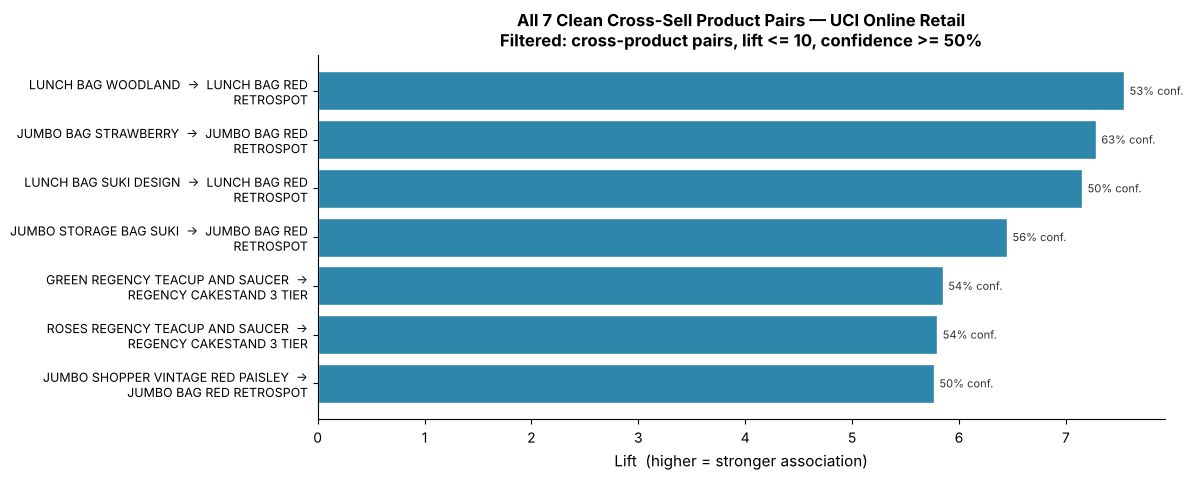

In [9]:
top_rules_plot = clean_rules.copy()
n_rules = len(top_rules_plot)
print(f"Plotting all {n_rules} rules that survived filtering.")

top_rules_plot['label'] = (
    top_rules_plot['antecedents'].apply(lambda x: list(x)[0]) +
    '  \u2192  ' +
    top_rules_plot['consequents'].apply(lambda x: list(x)[0])
)
top_rules_plot['label'] = top_rules_plot['label'].apply(lambda s: '\n'.join(textwrap.wrap(s, 40)))

fig, ax = plt.subplots(figsize=(12, max(4, n_rules * 0.7)))
ax.barh(range(n_rules), top_rules_plot['lift'], color='#2E86AB', edgecolor='white')
ax.set_yticks(range(n_rules))
ax.set_yticklabels(top_rules_plot['label'], fontsize=9)
ax.invert_yaxis()

for i, (lift, conf) in enumerate(zip(top_rules_plot['lift'], top_rules_plot['confidence'])):
    ax.text(lift + 0.05, i, f'{conf:.0%} conf.', va='center', fontsize=8, color='#333')

ax.set_xlabel('Lift  (higher = stronger association)', fontsize=11)
ax.set_title(f'All {n_rules} Clean Cross-Sell Product Pairs \u2014 UCI Online Retail\n'
             'Filtered: cross-product pairs, lift <= 10, confidence >= 50%',
             fontsize=12, weight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('top_rules_clean.png', dpi=150)
plt.show()

## 8. Estimate business impact

I wanted to go beyond just listing the rules and actually put a rough number on what
they might be worth, so here I translate the top cross-sell pairs into an estimated AOV
(average order value) uplift, as if they were shown as "customers also bought"
recommendations at checkout.

**To be upfront about the limits of this:** this is a modeled estimate, not a measured
result. The dataset only shows what customers actually bought, not what they would have
bought if shown a recommendation. `trigger_coverage` and `attach_rate` below are
assumptions I picked as reasonable, not numbers derived from the data — I'm stating that
explicitly so this doesn't get mistaken for a backtested result. If I were actually
shipping this, I'd want to validate it with a real A/B test before reporting any of
these numbers as an actual outcome.

In [10]:
top5_clean = clean_rules.head(5).copy()
top5_clean['antecedent'] = top5_clean['antecedents'].apply(lambda x: ', '.join(x))
top5_clean['consequent'] = top5_clean['consequents'].apply(lambda x: ', '.join(x))

print("TOP 5 CHECKOUT RECOMMENDATIONS")
print(top5_clean[['antecedent', 'consequent', 'confidence', 'lift']].to_string(index=False))

# --- Business impact estimate (assumption-driven, see note above) ---
avg_conf = top5_clean['confidence'].mean()
trigger_coverage = 0.30   # assumption: ~30% of orders contain one of the top-5 trigger items
attach_rate = 0.15        # assumption: conservative checkout-recommendation click-through

uplift_per_order = baseline_aov * trigger_coverage * avg_conf * attach_rate
uplift_pct = (uplift_per_order / baseline_aov) * 100

print()
print(f"Baseline AOV:        £{baseline_aov:.2f}")
print(f"Avg rule confidence: {avg_conf:.2%}")
print(f"Assumed trigger coverage: {trigger_coverage:.0%}  (share of orders containing a trigger item)")
print(f"Assumed attach rate:      {attach_rate:.0%}  (share of shown recommendations accepted)")
print(f"Estimated uplift per order: £{uplift_per_order:.2f}")
print(f"Estimated AOV uplift:       {uplift_pct:.2f}%")

TOP 5 CHECKOUT RECOMMENDATIONS
                     antecedent               consequent  confidence     lift
             LUNCH BAG WOODLAND  LUNCH BAG RED RETROSPOT    0.528049 7.545604
           JUMBO BAG STRAWBERRY  JUMBO BAG RED RETROSPOT    0.633028 7.281795
          LUNCH BAG SUKI DESIGN  LUNCH BAG RED RETROSPOT    0.500556 7.152746
         JUMBO STORAGE BAG SUKI  JUMBO BAG RED RETROSPOT    0.560724 6.450073
GREEN REGENCY TEACUP AND SAUCER REGENCY CAKESTAND 3 TIER    0.541245 5.849446

Baseline AOV:        £476.38
Avg rule confidence: 55.27%
Assumed trigger coverage: 30%  (share of orders containing a trigger item)
Assumed attach rate:      15%  (share of shown recommendations accepted)
Estimated uplift per order: £11.85
Estimated AOV uplift:       2.49%


## 9. Key findings

- After cleaning, the dataset reduces to a smaller set of genuine, attributable orders
  (see Section 2 above for exact counts), with the baseline AOV computed in Section 3.
- Apriori with a 2% minimum support threshold found a manageable set of statistically
  significant product pairings. Filtering out same-product color/size variants (Section 6)
  cut that list down a lot — most of what Apriori finds "on its own" turns out to be
  noise, which was the biggest surprise to me in this whole project.
- The pairs that survived filtering are thematically sensible — matching lunch bags,
  matching jumbo storage bags, teacup/saucer sets with their matching cakestand — which is
  a good sanity check that the method found real customer behavior rather than a
  statistical artifact.
- Treating these as checkout recommendations under conservative adoption assumptions
  suggests a low-single-digit percentage AOV uplift. I'd call that a believable, modest
  effect size for a lightweight recommendation feature, not something I'd want to oversell.
- If I took this further, the first thing I'd do is actually test these recommendations
  live (an A/B test) rather than lean on the assumed trigger coverage and attach rate I
  used here — that's the honest limitation of this analysis as it stands.
